In [33]:
#Imports and Creating Dataframe
import pandas as pd
import numpy as np
import missingno as msno
import regex



form_df = pd.read_excel("datasets/uncleaned_response_dataset.xlsx")

In [34]:
#initial inspection
print("Demo of Dataframe")
print(form_df.head())
print("\n Info about Dataframe Structure")
print(form_df.info())
print("\n Shape of the dataset")
print(form_df.shape)

Demo of Dataframe
                Timestamp Select your Faculty :  \
0 2026-06-13 10:31:53.030  Faculty Of Computing   
1 2026-06-16 21:21:39.131  Faculty Of Computing   
2 2026-06-16 21:34:31.372  Faculty Of Computing   
3 2026-06-16 21:39:51.402  Faculty Of Computing   
4 2026-06-16 21:48:27.564  Faculty Of Computing   

  Select your preferred Device Type : Brand Name :  \
0           Laptop / Desktop Computer       Lenovo   
1           Laptop / Desktop Computer       Lenovo   
2           Laptop / Desktop Computer         Asus   
3           Laptop / Desktop Computer       Lenovo   
4                        Mobile Phone        Apple   

  How did you choose the device (or the device brand) :  \
0                                  Personal Research      
1                         Salesperson Recommendation      
2                                  Personal Research      
3                                  Personal Research      
4                              Family Recommendation   

In [35]:
#Standardizing column headers
#This is done only to make addressing of columns easier in python
standardized_col_names  = {
    "TimeStamp" : "timestamp",
    "Select your Faculty :" : "faculty",
    "Select your preferred Device Type :" : "device_type",
    "Brand Name :":"brand_name",
    "How did you choose the device (or the device brand) :" : "chosen_method",
    "Battery Life Time (Normal Use) :" : "normal_use_battery_life(hours)",
    "Allocated Budget for the Device (in LKR) :  " : "budget",
    "Actual Price of the Device  (Budget limit can be  exceeded. ) :" : "device_price",
    "Payment Method :":"payment_method",
    "Total Storage Capacity ( HDD + NVME for PCs): " : "storage_capacity(GB)",
    "Expected Device Lifespan (in years) :" : "expected_life_span(years)",
    "Research Time before purchase the device (Approximately )  :" : "research_time",
    "Primary Factor influencing purchase :" : "primary_influence",
    "Weight of the Device :" : "weight(g)",
    "Where did you Purchase the Device :" : "store_type",
    "Are you satisfied with your choice ? " : "satisfaction",
    "RAM Size :":"ram_capacity(GB)",
    }

form_df.rename(columns=standardized_col_names,inplace=True)

print(form_df.head())
print(form_df.info())


                Timestamp               faculty                device_type  \
0 2026-06-13 10:31:53.030  Faculty Of Computing  Laptop / Desktop Computer   
1 2026-06-16 21:21:39.131  Faculty Of Computing  Laptop / Desktop Computer   
2 2026-06-16 21:34:31.372  Faculty Of Computing  Laptop / Desktop Computer   
3 2026-06-16 21:39:51.402  Faculty Of Computing  Laptop / Desktop Computer   
4 2026-06-16 21:48:27.564  Faculty Of Computing               Mobile Phone   

  brand_name               chosen_method normal_use_battery_life(hours)  \
0     Lenovo           Personal Research                      ~ 8 hours   
1     Lenovo  Salesperson Recommendation                     ~ 18 hours   
2       Asus           Personal Research                      ~ 8 hours   
3     Lenovo           Personal Research                      ~ 8 hours   
4      Apple       Family Recommendation                     ~ 10 hours   

   budget device_price                       payment_method  \
0  500000       4

In [36]:
# Cleaning Values
#extracting numerical values using regular expressions

regex_num_only = r"([0-9]+\.?[0-9]*)"
regex_num_unit = r"([0-9]+\.?[0-9]*)\s*([a-zA-Z]*)"


# if values are in a different unit 
# like when needed hours but provide days we create function to handle that

def clean_values(val, pattern, unit_multiplier:dict=None, is_price=False):
    """
        Paramets:
            val:String = Value to Check
            unit_multiplier:Dictionary  = Dictionary of Possible other units and their multiplier relative to standard unit 
            is_price:Boolean = whether this is a price col 

        This function extract numeric values and standardize into standard units if necessary
        also replaces Non numerical values to None So use with caution
    """
    #null value check
    if pd.isna(val):
        return val

    val = str(val).lower().strip()
    val = val.replace(",", "").replace(" ","").replace("1/2",".5")

    extracted_val = regex.search(pattern, val)

    if extracted_val:
        num_value = float(extracted_val.group(1))

        # because dataset about devices and device price can't be Rs.1000 or lower assumes it's in lakshs and multiply by 100000
        # also in srilanka most people use lakshs instead of milions
        if is_price:
            if num_value < 10:
                return num_value * 100000
            # in normal language we say 60 that means 600000 hence this fix
            elif num_value < 100:
                return num_value * 10000
        
        if unit_multiplier and len(extracted_val.groups()) > 1:
            unit = extracted_val.group(2)

            for key,multiplier in unit_multiplier.items():
                if key in unit:
                    return num_value * multiplier
        return num_value
    return None
# applying it to price colums
price_cols = ["budget","device_price"]

for col in price_cols:
    form_df[col] = form_df[col].apply(
        lambda x : clean_values(val=x,pattern=regex_num_only,unit_multiplier={},is_price=True)
    )


other_num_cols = {
    "normal_use_battery_life(hours)" : {"day": 24},
    "storage_capacity(GB)": {"tb":1024},
    "ram_capacity(GB)":{},
    "weight(g)": {"kg":1000},
    "expected_life_span(years)":{},
}

#applying it to other numerical cols
for col,multiplier_dict in other_num_cols.items():
    form_df[col] = form_df[col].apply(
        lambda x: clean_values(val=x,pattern=regex_num_unit,unit_multiplier=multiplier_dict,is_price=False)
    )



In [37]:
# Conveting columns to appropriate data type

# for numerical columns
num_cols = price_cols + list(other_num_cols.keys())

numeric_conversions_fails = []
    
for col in  num_cols:
    try:
        form_df[col] = pd.to_numeric(form_df[col])
    except ValueError:
        print(f"Coudn't convert {col} to numeric")

#for catgorical columns

non_num_cols = [col for col in form_df if form_df[col].dtype == "str"]

for col in non_num_cols:
    # fixing case of string before categorizing them
    form_df[col] = form_df[col].str.title().str.strip()
    # we use 15 here because later when training model can overfit if they are small number of values per category
    if form_df[col].nunique() <= 15:
        form_df[col] = form_df[col].astype("category")


<class 'pandas.DataFrame'>
Index: 159 entries, 0 to 160
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Timestamp                       159 non-null    datetime64[us]
 1   faculty                         159 non-null    category      
 2   device_type                     159 non-null    category      
 3   brand_name                      159 non-null    category      
 4   chosen_method                   159 non-null    category      
 5   normal_use_battery_life(hours)  159 non-null    float64       
 6   budget                          159 non-null    float64       
 7   device_price                    159 non-null    float64       
 8   payment_method                  159 non-null    category      
 9   storage_capacity(GB)            159 non-null    float64       
 10  expected_life_span(years)       159 non-null    float64       
 11  research_time         

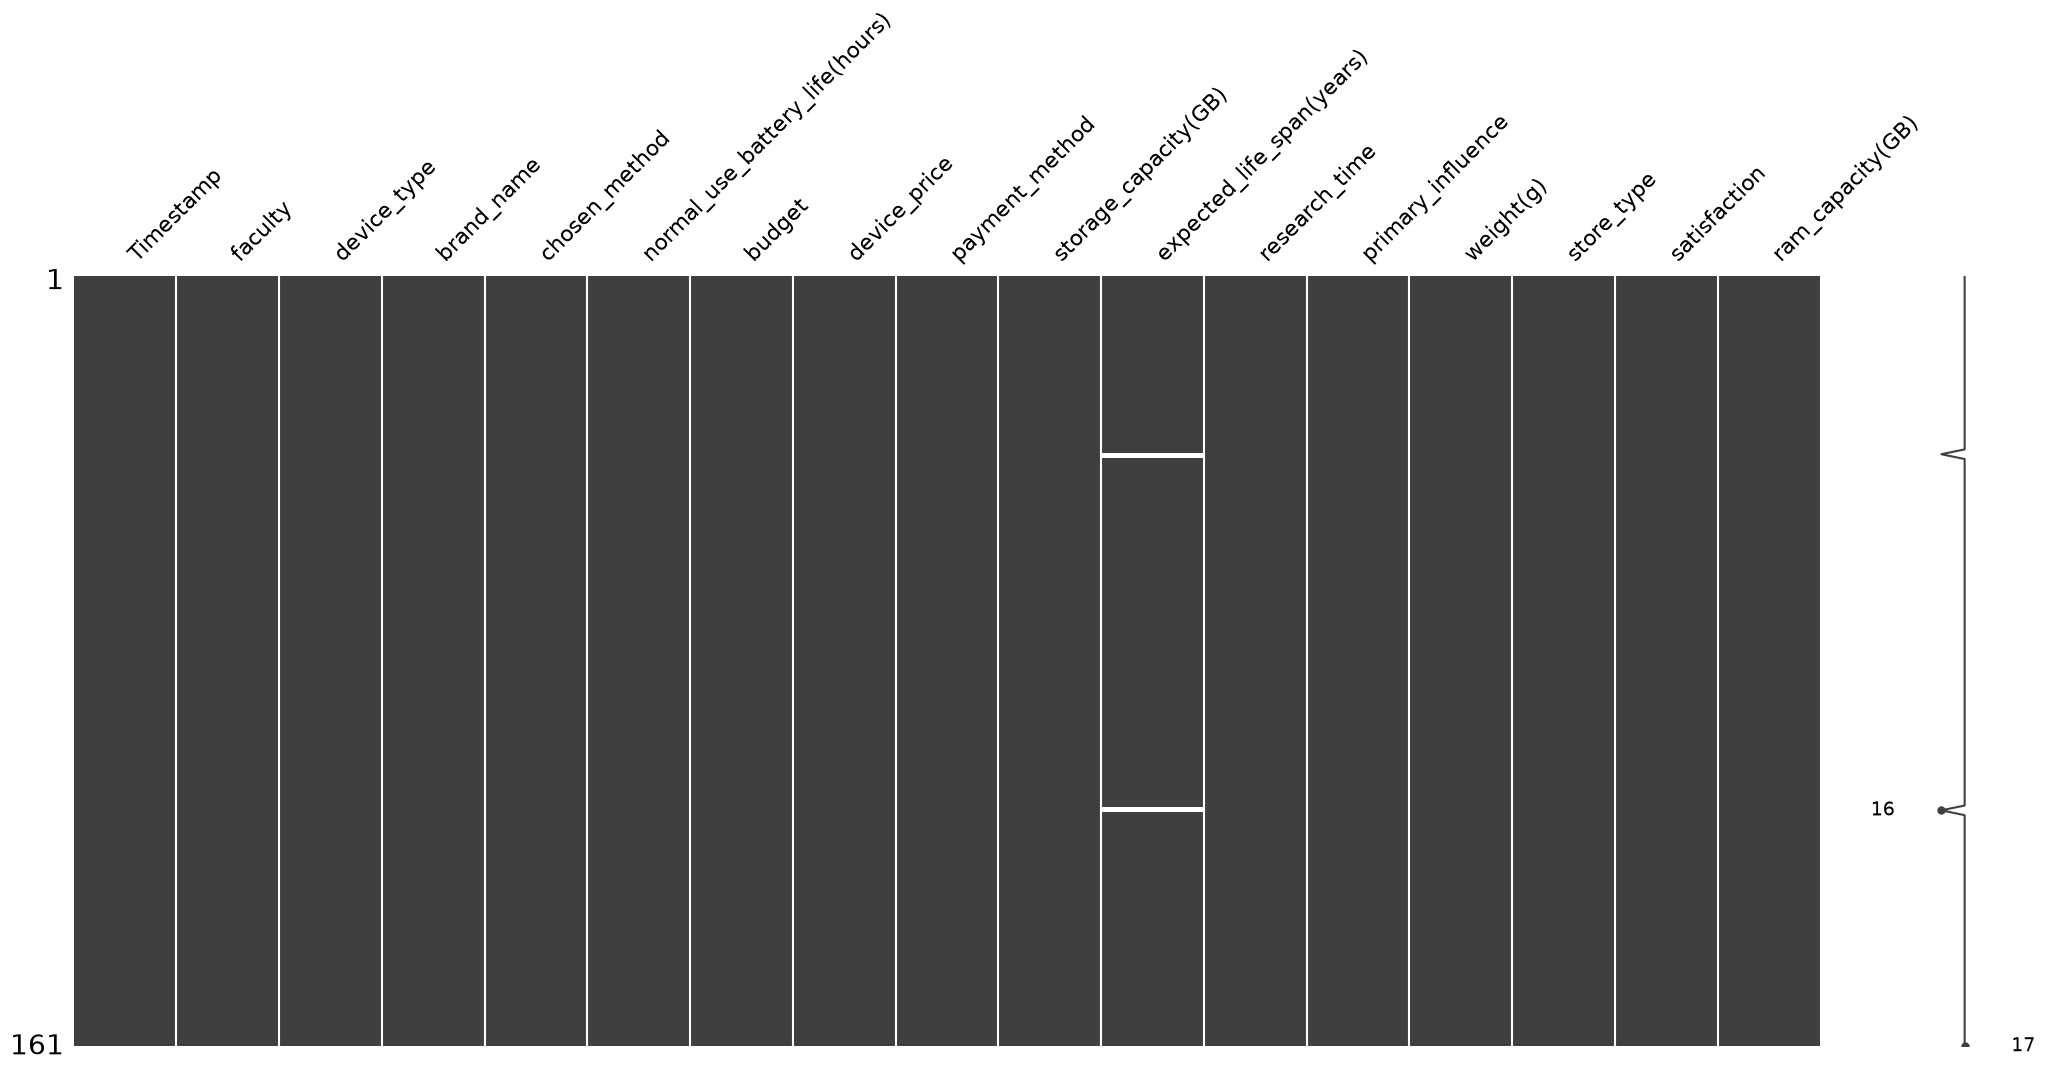

In [38]:
# Treating null values

# there's entire column that is null we drop that column
form_df.drop(columns=["Column 1"],inplace=True)


# visualising null values
msno.matrix(df=form_df)

#because total null values are less 5% of the data we drop it
form_df.dropna(inplace=True)

form_df.info()

In [39]:
# save the cleaned Dataset
form_df.to_excel("datasets/cleaned_response_dataset.xlsx")